In [1]:
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from torch_geometric.data import Data
import glob

# 1. Comprobación de hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de entrenamiento: {device}")
if torch.cuda.is_available():
    print(f"Tarjeta Gráfica: {torch.cuda.get_device_name(0)}")
    print(f"Memoria VRAM Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB\n")

# 2. Carga del dataset (Esto debería volar gracias a pyarrow/fastparquet)
print("Cargando el archivo Parquet...")

# Lista de todos los archivos .parquet en la carpeta actual
files = glob.glob("*.parquet")

# Carga cada archivo y concatena en un solo DataFrame
df = pd.concat([pd.read_parquet(file) for file in files], ignore_index=True)
print(f"Filas cargadas: {len(df):,}")

columna_etiqueta = 'label_tactic' 

# 1. Vamos a ver qué palabras exactas usaron los investigadores en tu archivo
print("Etiquetas únicas en el dataset:")
print(df[columna_etiqueta].unique())

# 2. Definimos qué textos significan "Tráfico Normal" en el dataset UWF
textos_benignos = ['none', 'None', 'NONE', '-', 'N/A', '', None]

# 3. Nueva regla: Es ataque SOLO si el texto NO está en nuestra lista de benignos
# Llenamos los nulos con 'none' por si acaso, y comprobamos
df['is_attack'] = (~df[columna_etiqueta].fillna('none').isin(textos_benignos)).astype(int)

print(f"Tráfico Benigno (0): {len(df[df['is_attack'] == 0]):,}")
print(f"Tráfico Malicioso/Ataques (1): {len(df[df['is_attack'] == 1]):,}")

Dispositivo de entrenamiento: cuda
Tarjeta Gráfica: NVIDIA GeForce RTX 5090
Memoria VRAM Total: 33.67 GB

Cargando el archivo Parquet...
Filas cargadas: 1,916,757
Etiquetas únicas en el dataset:
['Defense Evasion' 'Initial Access' 'Persistence' 'Privilege Escalation'
 'Reconnaissance' 'Credential Access' 'Exfiltration' 'none']
Tráfico Benigno (0): 958,109
Tráfico Malicioso/Ataques (1): 958,648


In [2]:
print("1. Mapeando IPs a nodos matemáticos...")
encoder = LabelEncoder()
# Ajusta los nombres de las columnas de IP Origen y Destino si son diferentes
todas_las_ips = pd.concat([df['src_ip_zeek'], df['dest_ip_zeek']]).unique()
encoder.fit(todas_las_ips)

src_nodos = encoder.transform(df['src_ip_zeek'])
dst_nodos = encoder.transform(df['dest_ip_zeek'])

print("2. Construyendo los tensores del grafo...")
# edge_index: Define quién se conecta con quién (Matriz 2 x N)
edge_index = torch.tensor(np.vstack((src_nodos, dst_nodos)), dtype=torch.long)

# edge_attr: Las características de la conexión que usará el modelo para detectar el ataque
# (Ajusta estas columnas según las numéricas que tengas en el parquet)
columnas_features = ['orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts', 'duration']
# Rellenamos nulos con 0 y convertimos a tensor
features_conexion = df[columnas_features].fillna(0).values
edge_attr = torch.tensor(features_conexion, dtype=torch.float)

# y: Nuestras etiquetas objetivo (lo que queremos predecir)
y = torch.tensor(df['is_attack'].values, dtype=torch.float)

# x: Características de los nodos (Por ahora ponemos un vector de "unos" genérico. 
# En el futuro, aquí es donde importarías los embeddings de GraphSAGE desde Neo4j)
num_nodos = len(todas_las_ips)
x = torch.ones((num_nodos, 1), dtype=torch.float)

print("3. Empaquetando y enviando a la RTX 5090...")
grafo_pyg = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# ¡Alimentamos la GPU!
grafo_pyg = grafo_pyg.to(device)

print("\n--- RESUMEN DEL GRAFO EN GPU ---")
print(grafo_pyg)
print(f"¿Está el grafo en la memoria de la gráfica? {grafo_pyg.is_cuda}")

1. Mapeando IPs a nodos matemáticos...
2. Construyendo los tensores del grafo...
3. Empaquetando y enviando a la RTX 5090...

--- RESUMEN DEL GRAFO EN GPU ---
Data(x=[357, 1], edge_index=[2, 1916757], edge_attr=[1916757, 5], y=[1916757])
¿Está el grafo en la memoria de la gráfica? True


In [3]:
import torch.nn as nn
from torch_geometric.nn import SAGEConv

print("1. Dividiendo conexiones (80% Train, 20% Test)...")
num_edges = grafo_pyg.num_edges
indices = torch.randperm(num_edges) # Mezclamos aleatoriamente
train_size = int(0.8 * num_edges)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

# Creamos "máscaras" (filtros booleanos) para decirle a PyTorch qué usar
grafo_pyg.train_mask = torch.zeros(num_edges, dtype=torch.bool)
grafo_pyg.train_mask[train_idx] = True

grafo_pyg.test_mask = torch.zeros(num_edges, dtype=torch.bool)
grafo_pyg.test_mask[test_idx] = True

print("2. Definiendo la Arquitectura de la Red Neuronal (GraphSAGE + MLP)...")
class DetectorAtaquesGNN(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, hidden_dim):
        super().__init__()
        # Capas de Grafos: Aprenden el "vecindario" de cada IP
        self.conv1 = SAGEConv(node_in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        
        # Capas Lineales: Deciden si es un ataque juntando nodos + conexion
        clf_in_dim = (hidden_dim * 2) + edge_in_dim
        self.clf = nn.Sequential(
            nn.Linear(clf_in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2), # Apagamos neuronas al azar para evitar sobreajuste
            nn.Linear(hidden_dim, 1) # Salida: 1 solo número (probabilidad)
        )
        
    def forward(self, x, edge_index, edge_attr):
        # 1. Propagación de mensajes (Contexto de IPs)
        h = self.conv1(x, edge_index).relu()
        h = self.conv2(h, edge_index).relu()
        
        # 2. Sacar los vectores exactos del Origen y el Destino para cada flecha
        src, dst = edge_index[0], edge_index[1]
        vec_origen = h[src]
        vec_destino = h[dst]
        
        # 3. Unir todo (Origen + Destino + Propiedades de la conexión)
        representacion_conexion = torch.cat([vec_origen, vec_destino, edge_attr], dim=-1)
        
        # 4. Clasificar
        return self.clf(representacion_conexion).squeeze()

# Instanciamos el modelo y lo mandamos a la GPU
# 1 feature de nodo, 5 de arista, 64 neuronas ocultas
modelo = DetectorAtaquesGNN(node_in_dim=1, edge_in_dim=5, hidden_dim=64).to(device)
print("¡Modelo creado y enviado a la RTX 5090!")

1. Dividiendo conexiones (80% Train, 20% Test)...
2. Definiendo la Arquitectura de la Red Neuronal (GraphSAGE + MLP)...
¡Modelo creado y enviado a la RTX 5090!


In [4]:
# Usamos BCEWithLogitsLoss (es más estable numéricamente que BCELoss)
criterion = nn.BCEWithLogitsLoss()
# Optimizador Adam, el estándar de la industria
optimizer = torch.optim.Adam(modelo.parameters(), lr=0.005)

epocas = 100

print(f"--- INICIANDO ENTRENAMIENTO EN {device.type.upper()} ---")
for epoch in range(1, epocas + 1):
    modelo.train()
    optimizer.zero_grad()
    
    # 1. Predicción (Hacia adelante)
    out = modelo(grafo_pyg.x, grafo_pyg.edge_index, grafo_pyg.edge_attr)
    
    # 2. Calcular el error SOLO con las flechas de entrenamiento
    loss = criterion(out[grafo_pyg.train_mask], grafo_pyg.y[grafo_pyg.train_mask])
    
    # 3. Retropropagación (Aprender de los errores)
    loss.backward()
    optimizer.step()
    
    # 4. Evaluación cada 10 épocas
    if epoch % 10 == 0:
        modelo.eval() # Modo evaluación (apaga el Dropout)
        with torch.no_grad():
            # Convertimos la salida a probabilidades y luego a 0s o 1s
            predicciones = (torch.sigmoid(out) > 0.5).float()
            
            # Calculamos Accuracy
            train_correct = (predicciones[grafo_pyg.train_mask] == grafo_pyg.y[grafo_pyg.train_mask]).sum()
            train_acc = train_correct / grafo_pyg.train_mask.sum()
            
            test_correct = (predicciones[grafo_pyg.test_mask] == grafo_pyg.y[grafo_pyg.test_mask]).sum()
            test_acc = test_correct / grafo_pyg.test_mask.sum()
            
        print(f'Época {epoch:03d} | Pérdida (Loss): {loss:.4f} | Accuracy Train: {train_acc:.4f} | Accuracy Test: {test_acc:.4f}')

print("\n¡Entrenamiento finalizado!")

--- INICIANDO ENTRENAMIENTO EN CUDA ---


Época 010 | Pérdida (Loss): 0.2249 | Accuracy Train: 0.9546 | Accuracy Test: 0.9534
Época 020 | Pérdida (Loss): 0.1400 | Accuracy Train: 0.9571 | Accuracy Test: 0.9567
Época 030 | Pérdida (Loss): 0.1090 | Accuracy Train: 0.9611 | Accuracy Test: 0.9607
Época 040 | Pérdida (Loss): 0.0746 | Accuracy Train: 0.9677 | Accuracy Test: 0.9675
Época 050 | Pérdida (Loss): 0.0627 | Accuracy Train: 0.9721 | Accuracy Test: 0.9720
Época 060 | Pérdida (Loss): 0.0545 | Accuracy Train: 0.9744 | Accuracy Test: 0.9743
Época 070 | Pérdida (Loss): 0.0496 | Accuracy Train: 0.9763 | Accuracy Test: 0.9762
Época 080 | Pérdida (Loss): 0.0451 | Accuracy Train: 0.9782 | Accuracy Test: 0.9781
Época 090 | Pérdida (Loss): 0.0417 | Accuracy Train: 0.9797 | Accuracy Test: 0.9797
Época 100 | Pérdida (Loss): 0.0400 | Accuracy Train: 0.9791 | Accuracy Test: 0.9791

¡Entrenamiento finalizado!


1. Evaluando el modelo final con el set de Test...

--- REPORTE DE CLASIFICACIÓN ---
                    precision    recall  f1-score   support

Tráfico Normal (0)       0.98      0.96      0.97    191953
        Ataque (1)       0.97      0.99      0.97    191399

          accuracy                           0.97    383352
         macro avg       0.97      0.97      0.97    383352
      weighted avg       0.97      0.97      0.97    383352

2. Guardando el modelo para Producción (Streaming)...
¡Modelo guardado como 'detector_mitre_gnn.pt'!


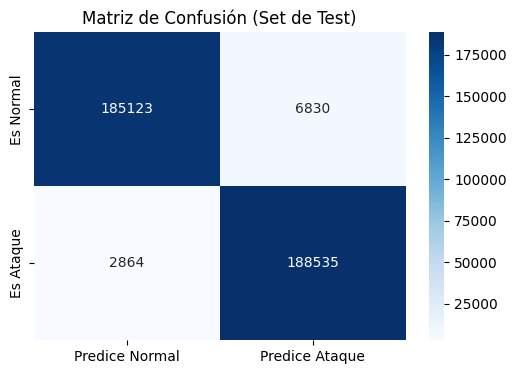

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("1. Evaluando el modelo final con el set de Test...")
modelo.eval()
with torch.no_grad():
    # Sacamos las predicciones
    out = modelo(grafo_pyg.x, grafo_pyg.edge_index, grafo_pyg.edge_attr)
    predicciones = (torch.sigmoid(out[grafo_pyg.test_mask]) > 0.5).int().cpu().numpy()
    
    # Sacamos las etiquetas reales
    etiquetas_reales = grafo_pyg.y[grafo_pyg.test_mask].int().cpu().numpy()

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(etiquetas_reales, predicciones, target_names=['Tráfico Normal (0)', 'Ataque (1)']))

print("2. Guardando el modelo para Producción (Streaming)...")
# Guardamos los pesos matemáticos en un archivo físico
torch.save(modelo.state_dict(), 'detector_mitre_gnn.pt')
print("¡Modelo guardado como 'detector_mitre_gnn.pt'!")

# 3. Dibujamos la Matriz de Confusión
cm = confusion_matrix(etiquetas_reales, predicciones)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predice Normal', 'Predice Ataque'], yticklabels=['Es Normal', 'Es Ataque'])
plt.title('Matriz de Confusión (Set de Test)')
plt.show()